In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep exp1.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values
print(X)
print(y)

[[11]
 [22]
 [33]
 [44]
 [55]
 [66]
 [77]
 [88]
 [99]
 [12]
 [13]
 [14]
 [15]
 [85]
 [96]]
[[95]
 [65]
 [13]
 [74]
 [68]
 [64]
 [62]
 [51]
 [73]
 [35]
 [89]
 [67]
 [55]
 [20]
 [17]]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [9]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [11]:
dataset1.head()

,Input,Output
0,11,95
1,22,65
2,33,13
3,44,74
4,55,68


In [12]:
# Name: Harini S
# Register Number:212223240048
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}

  def forward(self, x):
        # Include your code here
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(lig.parameters(), lr=0.001)


In [15]:
# Name: Harini S
# Register Number: 212223240048
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs) :
      optimizer. zero_grad()
      loss = criterion(ai_brain(X_train),y_train)
      loss. backward()
      optimizer.step()
      lig. history['loss'].append(loss.item())
      if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [16]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 3476.561035
Epoch [200/2000], Loss: 3024.474121
Epoch [400/2000], Loss: 2246.626465
Epoch [600/2000], Loss: 1327.242798
Epoch [800/2000], Loss: 603.243286
Epoch [1000/2000], Loss: 336.531525
Epoch [1200/2000], Loss: 312.251312
Epoch [1400/2000], Loss: 299.189697
Epoch [1600/2000], Loss: 289.627258
Epoch [1800/2000], Loss: 284.770813


In [17]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 1746.407959


Text(0, 0.5, 'Loss')

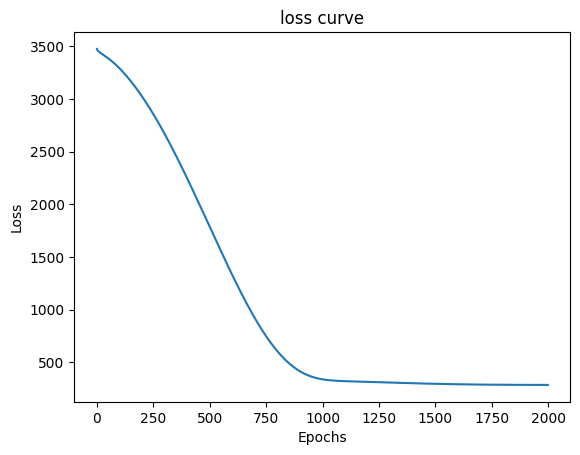

In [18]:
import matplotlib.pyplot as plt
plt.plot(lig. history[ 'loss'])
plt.title("loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

In [20]:
X_n1_1 = torch.tensor([[50]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 56.088401794433594
